## Import Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Set seed for reproducibility
np.random.seed(42)

## PART 1: PHYSICS SIMULATION (The Synthetic Dataset)

In [ ]:
def generate_drive_data(n_samples=2000):
    """
    Simulates accelerometer data for a car trip.
    Generates 'Normal' driving with injected 'Events'.
    """
    # Time vector (100Hz sample rate = 20 seconds)
    time = np.linspace(0, 20, n_samples)

    # Base: Normal driving with random road noise
    acc_x = np.random.normal(0, 0.05, n_samples) # Lateral (Turns)
    acc_y = np.random.normal(0, 0.05, n_samples) # Longitudinal (Speed)
    labels = np.zeros(n_samples) # 0 = Normal

    # Event 1: Aggressive Braking (Negative Spike in Y)
    # Objective 1: Detecting dynamics without OBD-II
    for i in range(200, 250):
        acc_y[i] -= np.random.uniform(0.6, 1.2)
        labels[i] = 1 # Label 1 = Hard Brake

    # Event 2: Aggressive Turn (Spike in X)
    for i in range(800, 850):
        acc_x[i] += np.random.uniform(0.6, 1.2)
        labels[i] = 2 # Label 2 = Hard Turn

    # Event 3: Sudden Acceleration (Positive Spike in Y)
    for i in range(1400, 1450):
        acc_y[i] += np.random.uniform(0.5, 1.0)
        labels[i] = 3 # Label 3 = Sudden Accel

    # Add extra "Phone Noise" (Vibrations) to test robustness
    noise_x = np.random.normal(0, 0.02, n_samples)
    noise_y = np.random.normal(0, 0.02, n_samples)

    df = pd.DataFrame({
        'time': time,
        'raw_acc_x': acc_x + noise_x,
        'raw_acc_y': acc_y + noise_y,
        'true_label': labels
    })
    return df

# Generate the trip data
print("Generating synthetic driving dataset")
df = generate_drive_data(n_samples=2000)

Generating synthetic driving dataset


In [ ]:
sampled_data = pd.DataFrame()
for label in df['true_label'].unique():
    sampled_data = pd.concat([sampled_data, df[df['true_label'] == label].head(3)])

# Sort by time for better readability
sampled_data = sampled_data.sort_values(by='time').reset_index(drop=True)

print(sampled_data.to_markdown(index=False, numalign="left", stralign="left"))

| time     | raw_acc_x   | raw_acc_y   | true_label   |
|:---------|:------------|:------------|:-------------|
| 0        | 0.0157398   | -0.0227196  | 0            |
| 0.010005 | -0.0277093  | -0.0141079  | 0            |
| 0.02001  | 0.0202315   | -0.0419104  | 0            |
| 2.001    | 0.0209792   | -0.781647   | 1            |
| 2.01101  | 0.0213082   | -0.662909   | 1            |
| 2.02101  | 0.0537551   | -1.12282    | 1            |
| 8.004    | 0.707671    | 0.0442102   | 2            |
| 8.01401  | 0.891433    | 0.134021    | 2            |
| 8.02401  | 1.18576     | 0.0226375   | 2            |
| 14.007   | -0.0771368  | 0.487496    | 3            |
| 14.017   | -0.00322477 | 0.559105    | 3            |
| 14.027   | 0.0443664   | 0.752395    | 3            |


***true_label*** is:

0 for 'Normal' driving

1 for 'Hard Brake'

2 for 'Hard Turn'

3 for 'Sudden Acceleration'

Each with a few representative rows.

## PART 2: PRE-PROCESSING (Objective 3: Noise Reduction)

In [ ]:
# Apply Low-Pass Filter (Rolling Mean) to remove high-freq vibrations
window_size = 10
df['acc_x'] = df['raw_acc_x'].rolling(window=window_size).mean().fillna(0)
df['acc_y'] = df['raw_acc_y'].rolling(window=window_size).mean().fillna(0)

## PART 3: FEATURE ENGINEERING

In [ ]:
# 1. Magnitude: Total G-Force experienced
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2)

# 2. Jerk: Rate of change of acceleration (Whiplash effect)
# Objective 5: Quantifying Aggressiveness
df['jerk'] = df['acc_mag'].diff().fillna(0)

# Prepare Data for AI
# We drop the first few rows (NaNs from rolling window)
features = ['acc_x', 'acc_y', 'acc_mag', 'jerk']
X = df[features]
y = df['true_label']

## PART 4: AI MODEL TRAINING (Objective 3: ML Classifier)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Random Forest is robust against noise and non-linear data
clf = RandomForestClassifier(n_estimators=100, max_depth=10)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation
target_names = ['Normal', 'Hard Brake', 'Hard Turn', 'Sudden Accel']
print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))


--- Model Performance Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       558
  Hard Brake       0.94      1.00      0.97        17
   Hard Turn       1.00      1.00      1.00        10
Sudden Accel       0.94      1.00      0.97        15

    accuracy                           1.00       600
   macro avg       0.97      1.00      0.98       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Random Forest Metrics (already computed) ---
# The y_pred from the previous cell is used directly
rf_report = classification_report(y_test, y_pred, output_dict=True)
rf_cm = confusion_matrix(y_test, y_pred)

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Macro Avg Precision': rf_report['macro avg']['precision'],
    'Macro Avg Recall': rf_report['macro avg']['recall'],
    'Macro Avg F1-score': rf_report['macro avg']['f1-score'],
}

# Calculate Macro Avg FPR for Random Forest
fprs_rf = []
num_classes = len(np.unique(y_test)) # Number of unique classes in the test set
for i in range(num_classes):
    FP = rf_cm[:, i].sum() - rf_cm[i, i] # Sum of column i (predicted as i) minus true positives for i
    TN = rf_cm.sum() - rf_cm[i, :].sum() - FP - rf_cm[i,i] # Total - (TP + FN for class i) - FP for class i
    if (FP + TN) > 0:
        fprs_rf.append(FP / (FP + TN))
    else:
        fprs_rf.append(0.0) # Avoid division by zero if a class has no TN/FP
rf_metrics['Macro Avg FPR'] = np.mean(fprs_rf)

# --- 2. Basic Decision Tree Metrics ---
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_dt_pred = dt_clf.predict(X_test)

dt_report = classification_report(y_test, y_dt_pred, output_dict=True)
dt_cm = confusion_matrix(y_test, y_dt_pred)

dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_dt_pred),
    'Macro Avg Precision': dt_report['macro avg']['precision'],
    'Macro Avg Recall': dt_report['macro avg']['recall'],
    'Macro Avg F1-score': dt_report['macro avg']['f1-score'],
}

# Calculate Macro Avg FPR for Decision Tree
fprs_dt = []
for i in range(num_classes):
    FP = dt_cm[:, i].sum() - dt_cm[i, i]
    TN = dt_cm.sum() - dt_cm[i, :].sum() - FP - dt_cm[i,i]
    if (FP + TN) > 0:
        fprs_dt.append(FP / (FP + TN))
    else:
        fprs_dt.append(0.0)
dt_metrics['Macro Avg FPR'] = np.mean(fprs_dt)

# --- 3. Baseline (Threshold) Metrics ---
# Define a simple rule-based classifier for the baseline
def predict_baseline(X_data):
    predictions = np.zeros(len(X_data))
    # Iterate with a sequential index 'j' for the predictions array
    for j, (idx, row) in enumerate(X_data.iterrows()):
        if row['acc_y'] < -0.5: # Hard Brake
            predictions[j] = 1
        elif row['acc_x'] > 0.5: # Hard Turn
            predictions[j] = 2
        elif row['acc_y'] > 0.5: # Sudden Accel
            predictions[j] = 3
        else: # Normal
            predictions[j] = 0
    return predictions

# Generate predictions for the baseline model using X_test
y_baseline_pred = predict_baseline(X_test)

baseline_report = classification_report(y_test, y_baseline_pred, output_dict=True, zero_division=0)
baseline_cm = confusion_matrix(y_test, y_baseline_pred)

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_baseline_pred),
    'Macro Avg Precision': baseline_report['macro avg']['precision'],
    'Macro Avg Recall': baseline_report['macro avg']['recall'],
    'Macro Avg F1-score': baseline_report['macro avg']['f1-score'],
}

# Calculate Macro Avg FPR for Baseline
fprs_baseline = []
for i in range(num_classes):
    FP = baseline_cm[:, i].sum() - baseline_cm[i, i]
    TN = baseline_cm.sum() - baseline_cm[i, :].sum() - FP - baseline_cm[i,i]
    if (FP + TN) > 0:
        fprs_baseline.append(FP / (FP + TN))
    else:
        fprs_baseline.append(0.0)
baseline_metrics['Macro Avg FPR'] = np.mean(fprs_baseline)

# --- 4. Combine into a DataFrame ---
metrics_df = pd.DataFrame({
    'Metric': list(rf_metrics.keys()),
    'Baseline (Threshold)': list(baseline_metrics.values()),
    'Basic Decision Tree': list(dt_metrics.values()),
    'Proposed Model (Random Forest)': list(rf_metrics.values())
})

print(metrics_df.round(4).to_markdown(index=False))

| Metric              |   Baseline (Threshold) |   Basic Decision Tree |   Proposed Model (Random Forest) |
|:--------------------|-----------------------:|----------------------:|---------------------------------:|
| Accuracy            |                 0.9883 |                     1 |                           0.9967 |
| Macro Avg Precision |                 0.9406 |                     1 |                           0.9705 |
| Macro Avg Recall    |                 0.9256 |                     1 |                           0.9991 |
| Macro Avg F1-score  |                 0.9329 |                     1 |                           0.9843 |
| Macro Avg FPR       |                 0.0013 |                     0 |                           0.0009 |


## PART 5: THE SAFETY SCORE (Objective 5: Scoring)

In [ ]:
def calculate_trip_score(predictions):
    base_score = 100
    # Weights: How "bad" is each event?
    penalties = {
        0: 0,   # Normal
        1: 5,   # Hard Brake (Dangerous)
        2: 5,   # Hard Turn (Dangerous)
        3: 2    # Sudden Accel (Wasteful/Risky)
    }

    total_penalty = sum([penalties.get(p, 0) for p in predictions])

    # Normalize by trip length (simulation is short, so we scale down penalty for demo)
    # In real life: penalty_per_mile
    final_score = max(0, base_score - (total_penalty * 0.1))
    return round(final_score, 2)

trip_score = calculate_trip_score(y_pred)
print(f"\n TRIP SAFETY SCORE: {trip_score}/100")


 TRIP SAFETY SCORE: 82.8/100


## PART 6: VISUALIZATION


Generating Telematics Profile Plot...


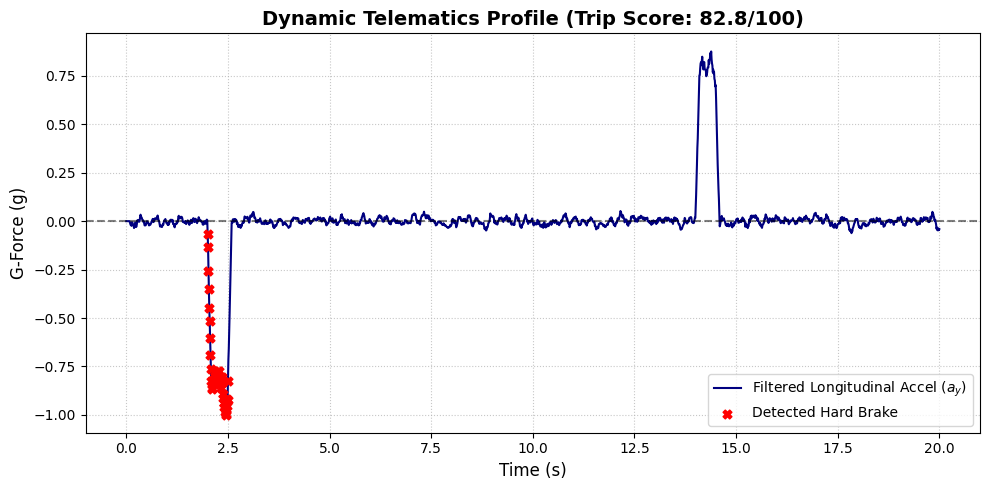

In [ ]:
# ==========================================
# VISUALIZATION 1: REAL-TIME EVENT DETECTION
# ==========================================
print("\nGenerating Telematics Profile Plot...")
plt.figure(figsize=(10, 5))

# Plot Longitudinal Acceleration with academic IEEE colors (Navy)
plt.plot(df['time'], df['acc_y'], label='Filtered Longitudinal Accel ($a_y$)', color='navy', linewidth=1.5)

# Highlight Detected Hard Brakes with prominent markers
all_preds = clf.predict(X)
brake_indices = np.where(all_preds == 1)[0]
plt.scatter(df.iloc[brake_indices]['time'], df.iloc[brake_indices]['acc_y'],
            color='red', label='Detected Hard Brake', zorder=5, s=40, marker='X')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title(f"Dynamic Telematics Profile (Trip Score: {trip_score}/100)", fontsize=14, fontweight='bold')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("G-Force (g)", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Save a high-resolution version for the Word Document
plt.tight_layout()
plt.savefig('Telematics_Profile_Plot.png', dpi=300)
plt.show()


Generating Normal Driving Profile Plot...


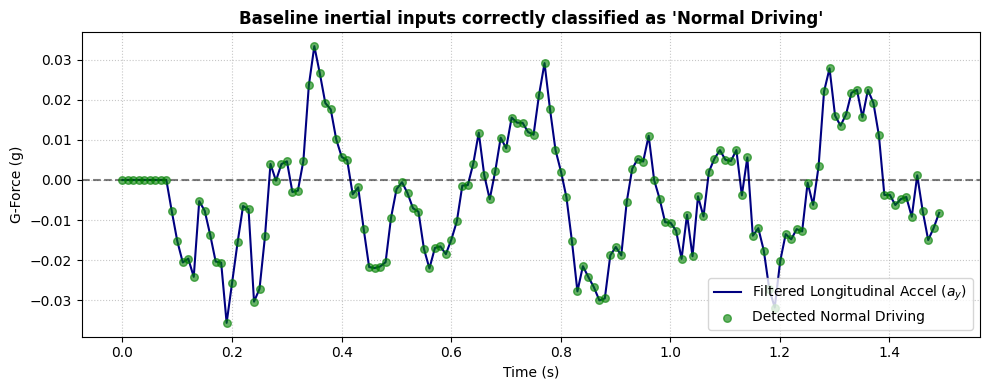


Generating Aggressive Maneuver Profile Plot...


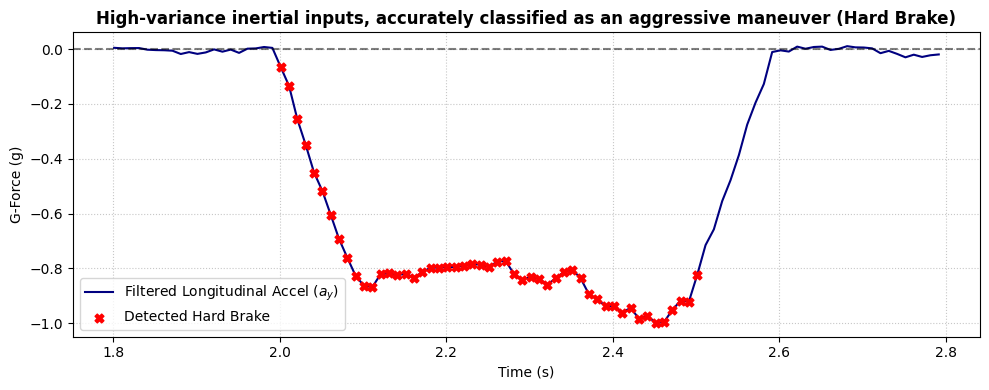

In [ ]:
print("\nGenerating Normal Driving Profile Plot...")
plt.figure(figsize=(10, 4))

# Select a time window for normal driving (e.g., first 1.5 seconds)
normal_start_time = 0
normal_end_time = 1.5
normal_df = df[(df['time'] >= normal_start_time) & (df['time'] <= normal_end_time)]
normal_preds = all_preds[normal_df.index]

plt.plot(normal_df['time'], normal_df['acc_y'], label='Filtered Longitudinal Accel ($a_y$)', color='navy', linewidth=1.5)

# Highlight detected "Normal" classifications (which should be most/all)
normal_classified_indices = np.where(normal_preds == 0)[0]
plt.scatter(normal_df.iloc[normal_classified_indices]['time'], normal_df.iloc[normal_classified_indices]['acc_y'],
            color='green', label='Detected Normal Driving', zorder=5, s=30, alpha=0.6, marker='o')


plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Baseline inertial inputs correctly classified as 'Normal Driving'", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)", fontsize=10)
plt.ylabel("G-Force (g)", fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('Normal_Driving_Classification.png', dpi=300)
plt.show()

# --- Figure 2: Aggressive Maneuver (Hard Brake Example) ---
print("\nGenerating Aggressive Maneuver Profile Plot...")
plt.figure(figsize=(10, 4))

# Select a time window around a hard brake event (e.g., 1.8 to 2.8 seconds)
event_start_time = 1.8
event_end_time = 2.8
event_df = df[(df['time'] >= event_start_time) & (df['time'] <= event_end_time)]
event_preds = all_preds[event_df.index]

plt.plot(event_df['time'], event_df['acc_y'], label='Filtered Longitudinal Accel ($a_y$)', color='navy', linewidth=1.5)

# Highlight Detected Hard Brakes within this specific window
brake_indices_in_window = np.where(event_preds == 1)[0]
plt.scatter(event_df.iloc[brake_indices_in_window]['time'], event_df.iloc[brake_indices_in_window]['acc_y'],
            color='red', label='Detected Hard Brake', zorder=5, s=40, marker='X')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("High-variance inertial inputs, accurately classified as an aggressive maneuver (Hard Brake)", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)", fontsize=10)
plt.ylabel("G-Force (g)", fontsize=10)
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('Aggressive_Maneuver_Classification.png', dpi=300)
plt.show()

Generating Learning Curve...


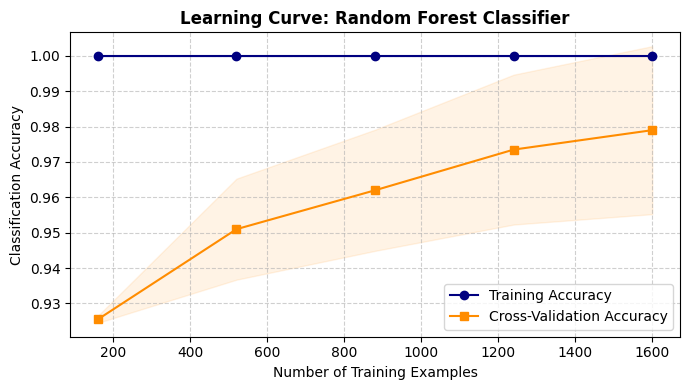

In [ ]:
# ==========================================
# VISUALIZATION 2: MODEL LEARNING CURVE
# ==========================================
from sklearn.model_selection import learning_curve

print("Generating Learning Curve...")
train_sizes, train_scores, test_scores = learning_curve(
    clf, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(7, 4))

# Use Navy and Dark Orange instead of standard Red/Green for print-friendly contrast
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="navy")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")

plt.plot(train_sizes, train_scores_mean, 'o-', color="navy", label="Training Accuracy")
plt.plot(train_sizes, test_scores_mean, 's-', color="darkorange", label="Cross-Validation Accuracy")

plt.title("Learning Curve: Random Forest Classifier", fontsize=12, fontweight='bold')
plt.xlabel("Number of Training Examples", fontsize=10)
plt.ylabel("Classification Accuracy", fontsize=10) # PERFECTED ACADEMIC LABEL
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right")

# Save a high-resolution version for the Word Document
plt.tight_layout()
plt.savefig('RF_Learning_Curve_Academic.png', dpi=300)
plt.show()